In [16]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/waste_project/"
CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES  = len(CLASS_NAMES)
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32

# Load the .npy files saved in Part 1
X_train = np.load(SAVE_DIR + "X_train.npy")
X_val   = np.load(SAVE_DIR + "X_val.npy")
X_test  = np.load(SAVE_DIR + "X_test.npy")
y_train = np.load(SAVE_DIR + "y_train.npy")
y_val   = np.load(SAVE_DIR + "y_val.npy")
y_test  = np.load(SAVE_DIR + "y_test.npy")

print("Data loaded successfully!")
print(f"  X_train : {X_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully!
  X_train : (1819, 224, 224, 3)
  X_val   : (455, 224, 224, 3)
  X_test  : (253, 224, 224, 3)


In [17]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

# KEY FIX: preprocessing_function=preprocess_input
# This converts [0,255] → [-1, +1] which is what MobileNetV2 expects
# It runs automatically on every batch before feeding to the model

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ← THIS is the fix
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # ← validation needs it too
)

train_gen = train_datagen.flow(X_train, y_train_cat,
                                batch_size=BATCH_SIZE, shuffle=True)
val_gen   = val_datagen.flow(X_val, y_val_cat,
                              batch_size=BATCH_SIZE, shuffle=False)

print("Generators ready!")
print(f"  Train batches per epoch : {len(X_train) // BATCH_SIZE}")
print(f"  Val   batches per epoch : {len(X_val)   // BATCH_SIZE}")
print("\n  Preprocessing: MobileNetV2 scale [-1, +1] applied per batch")

Generators ready!
  Train batches per epoch : 56
  Val   batches per epoch : 14

  Preprocessing: MobileNetV2 scale [-1, +1] applied per batch


In [19]:
def build_model(num_classes, learning_rate=0.001):
    """
    MobileNetV2 as base (frozen) + our custom classification head on top.

    Why MobileNetV2?
    - Already trained on 1.4 million images (ImageNet)
    - It already knows how to detect edges, textures, shapes
    - We just teach it to apply that knowledge to waste images
    - Fast to train, high accuracy even on small datasets
    """

    # Load MobileNetV2 WITHOUT its original top layer
    # include_top=False means we remove the ImageNet classifier
    # weights='imagenet' means load pretrained weights
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # FREEZE all base model layers — we won't train them yet
    # They already know useful features from ImageNet
    base_model.trainable = False

    print(f"Base model layers     : {len(base_model.layers)}")
    print(f"Trainable layers now  : {sum(1 for l in base_model.layers if l.trainable)}")

    # Build our classification head on top
    inputs = Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    # training=False keeps BatchNorm in inference mode (important when frozen)

    x = GlobalAveragePooling2D()(x)
    # Converts (7,7,1280) feature map → (1280,) flat vector

    x = BatchNormalization()(x)
    # Normalizes activations → more stable training

    x = Dense(256, activation='relu')(x)
    # Learns waste-specific patterns from MobileNetV2 features

    x = Dropout(0.4)(x)
    # Randomly drops 40% of neurons → prevents memorizing training data

    x = Dense(128, activation='relu')(x)

    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    # softmax → outputs 6 probabilities that sum to 1.0

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

model, base_model = build_model(NUM_CLASSES, learning_rate=0.001)
model.summary()

Base model layers     : 154
Trainable layers now  : 0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,710 (10.01 MB)

 Trainable params: 364,166 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [20]:
# Callbacks are automatic actions that happen during training

MODEL_PATH = SAVE_DIR + "waste_model_stage1.h5"

callbacks_stage1 = [

    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_accuracy',    # watch validation accuracy
        save_best_only=True,       # only save when it improves
        verbose=1
    ),

    EarlyStopping(
        monitor='val_accuracy',
        patience=5,                # stop if no improvement for 5 epochs
        restore_best_weights=True, # revert to best weights when stopped
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                # cut learning rate in half
        patience=3,                # after 3 epochs of no improvement
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks set up!")
print(f"Best model will be saved to: {MODEL_PATH}")

Callbacks set up!
Best model will be saved to: /content/drive/MyDrive/waste_project/waste_model_stage1.h5


In [21]:
print("=" * 50)
print("  STAGE 1 TRAINING — frozen base, training head only")
print("=" * 50)

EPOCHS_STAGE1 = 20

history_stage1 = model.fit(
    train_gen,
    steps_per_epoch  = len(X_train) // BATCH_SIZE,
    validation_data  = val_gen,
    validation_steps = len(X_val) // BATCH_SIZE,
    epochs           = EPOCHS_STAGE1,
    callbacks        = callbacks_stage1,
    verbose          = 1
)

# Evaluate on validation set after stage 1
val_loss, val_acc = model.evaluate(
    val_gen, steps=len(X_val) // BATCH_SIZE, verbose=0
)
print(f"\nStage 1 complete!")
print(f"  Validation accuracy : {val_acc*100:.2f}%")
print(f"  Validation loss     : {val_loss:.4f}")

  STAGE 1 TRAINING — frozen base, training head only
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.4668 - loss: 1.4588
Epoch 1: val_accuracy improved from None to 0.78348, saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 621ms/step - accuracy: 0.5859 - loss: 1.1407 - val_accuracy: 0.7835 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 2/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7188 - loss: 0.8620

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.78348
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7188 - loss: 0.8620 - val_accuracy: 0.7812 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7450 - loss: 0.6987
Epoch 3: val_accuracy improved from 0.78348 to 0.81920, saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 434ms/step - accuracy: 0.7577 - loss: 0.6830 - val_accuracy: 0.8192 - val_loss: 0.5654 - learning_rate: 0.0010
Epoch 4/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7500 - loss: 0.8331
Epoch 4: val_accuracy improved from 0.81920 to 0.82589, saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7500 - loss: 0.8331 - val_accuracy: 0.8259 - val_loss: 0.5584 - learning_rate: 0.0010
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.7941 - loss: 0.5509
Epoch 5: val_accuracy improved from 0.82589 to 0.85938, saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5



Epoch 5: finished saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 459ms/step - accuracy: 0.8081 - loss: 0.5326 - val_accuracy: 0.8594 - val_loss: 0.4518 - learning_rate: 0.0010
Epoch 6/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7500 - loss: 0.7905
Epoch 6: val_accuracy did not improve from 0.85938
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7500 - loss: 0.7905 - val_accuracy: 0.8571 - val_loss: 0.4524 - learning_rate: 0.0010
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8315 - loss: 0.4608
Epoch 7: val_accuracy improved from 0.85938 to 0.86384, saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5



Epoch 7: finished saving model to /content/drive/MyDrive/waste_project/waste_model_stage1.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 466ms/step - accuracy: 0.8310 - loss: 0.4908 - val_accuracy: 0.8638 - val_loss: 0.4022 - learning_rate: 0.0010
Epoch 8/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8438 - loss: 0.2791
Epoch 8: val_accuracy did not improve from 0.86384
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8438 - loss: 0.2791 - val_accuracy: 0.8638 - val_loss: 0.4027 - learning_rate: 0.0010
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8540 - loss: 0.4275
Epoch 9: val_accuracy did not improve from 0.86384
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 444ms/step - accuracy: 0.8528 - loss: 0.4171 - val_accuracy: 0.8504 - val_loss: 0.4334 - learning_rate: 0.0010
Epoch 10/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8125 - loss: 0.2990
Epoch 10: val_accuracy did not improve from 0.86384

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.000500000023748

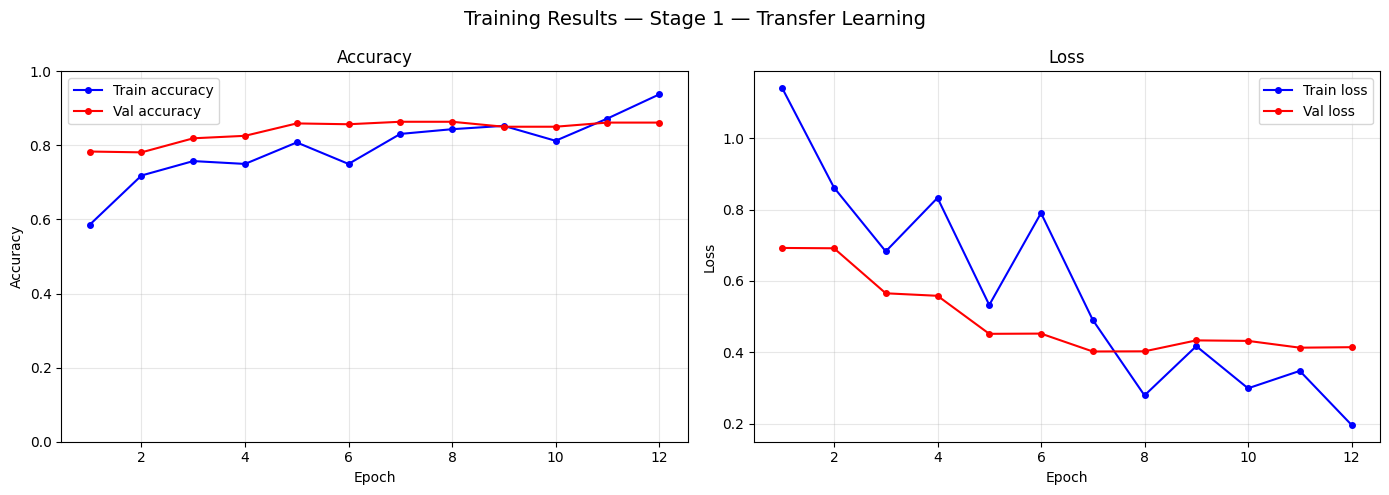

Plot saved: /content/drive/MyDrive/waste_project/plot_stage_1_—_transfer_learning.png


In [22]:
def plot_history(history, stage_name="Stage 1"):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs  = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Results — {stage_name}', fontsize=14)

    ax1.plot(epochs, acc,     'b-o', markersize=4, label='Train accuracy')
    ax1.plot(epochs, val_acc, 'r-o', markersize=4, label='Val accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(epochs, loss,     'b-o', markersize=4, label='Train loss')
    ax2.plot(epochs, val_loss, 'r-o', markersize=4, label='Val loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = SAVE_DIR + f"plot_{stage_name.lower().replace(' ','_')}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Plot saved: {save_path}")

plot_history(history_stage1, "Stage 1 — Transfer Learning")

In [23]:
# Get final val accuracy from training history
final_val_acc = max(history_stage1.history['val_accuracy'])

print("=" * 50)
print(f"  Stage 1 best val accuracy: {final_val_acc*100:.2f}%")
print("=" * 50)

if final_val_acc >= 0.88:
    print("\n  Accuracy is GOOD (>=88%)")
    print("  Fine-tuning is OPTIONAL — skip to Part 3 if happy")
elif final_val_acc >= 0.80:
    print("\n  Accuracy is ACCEPTABLE (80–88%)")
    print("  Fine-tuning RECOMMENDED — run Stage 2 below")
else:
    print("\n  Accuracy is LOW (<80%)")
    print("  Fine-tuning is REQUIRED — must run Stage 2")

print("\n  Run Stage 2 (fine-tuning) cell below regardless to get best results.")

  Stage 1 best val accuracy: 86.38%

  Accuracy is ACCEPTABLE (80–88%)
  Fine-tuning RECOMMENDED — run Stage 2 below

  Run Stage 2 (fine-tuning) cell below regardless to get best results.


In [24]:
print("=" * 50)
print("  STAGE 2 — Fine-tuning (unfreezing last 40 layers)")
print("=" * 50)

# Load the best model from Stage 1
model.load_weights(SAVE_DIR + "waste_model_stage1.h5")

# Unfreeze the ENTIRE base model first
base_model.trainable = True

# Then re-freeze everything EXCEPT the last 40 layers
# MobileNetV2 has 155 layers total
# Last 40 layers learned high-level features — most useful to tune
FINE_TUNE_FROM = len(base_model.layers) - 40

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False        # keep these frozen

for layer in base_model.layers[FINE_TUNE_FROM:]:
    layer.trainable = True         # fine-tune these

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Total layers in model     : {len(model.layers)}")
print(f"Trainable layers now      : {trainable_count}")
print(f"Fine-tuning from layer    : {FINE_TUNE_FROM} onwards")

# VERY important: use a much smaller learning rate for fine-tuning
# Large LR would destroy the pretrained weights we want to adjust gently
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 100x smaller than Stage 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

MODEL_PATH_FT = SAVE_DIR + "waste_model_finetuned.h5"

callbacks_stage2 = [
    ModelCheckpoint(
        filepath=MODEL_PATH_FT,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,                # more patience in fine-tuning
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]

print("\nStarting fine-tuning...")

history_stage2 = model.fit(
    train_gen,
    steps_per_epoch  = len(X_train) // BATCH_SIZE,
    validation_data  = val_gen,
    validation_steps = len(X_val) // BATCH_SIZE,
    epochs           = 20,
    callbacks        = callbacks_stage2,
    verbose          = 1
)

val_loss_ft, val_acc_ft = model.evaluate(
    val_gen, steps=len(X_val) // BATCH_SIZE, verbose=0
)
print(f"\nStage 2 complete!")
print(f"  Validation accuracy after fine-tuning : {val_acc_ft*100:.2f}%")
print(f"  Improvement from Stage 1              : +{(val_acc_ft - final_val_acc)*100:.2f}%")

  STAGE 2 — Fine-tuning (unfreezing last 40 layers)
Total layers in model     : 9
Trainable layers now      : 9
Fine-tuning from layer    : 114 onwards

Starting fine-tuning...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7503 - loss: 0.6437
Epoch 1: val_accuracy improved from None to 0.85045, saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5



Epoch 1: finished saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 60s 712ms/step - accuracy: 0.7655 - loss: 0.6417 - val_accuracy: 0.8504 - val_loss: 0.4060 - learning_rate: 1.0000e-05
Epoch 2/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7500 - loss: 0.5697
Epoch 2: val_accuracy did not improve from 0.85045
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7500 - loss: 0.5697 - val_accuracy: 0.8504 - val_loss: 0.4060 - learning_rate: 1.0000e-05
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7913 - loss: 0.5772
Epoch 3: val_accuracy did not improve from 0.85045
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 441ms/step - accuracy: 0.7969 - loss: 0.5666 - val_accuracy: 0.8482 - val_loss: 0.4191 - learning_rate: 1.0000e-05
Epoch 4/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8438 - loss: 0.7269
Epoch 4: val_accuracy did not improve from 0.85045

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999


Epoch 5: finished saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 497ms/step - accuracy: 0.7985 - loss: 0.5517 - val_accuracy: 0.8549 - val_loss: 0.4251 - learning_rate: 5.0000e-06
Epoch 6/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7812 - loss: 0.6123
Epoch 6: val_accuracy did not improve from 0.85491
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7812 - loss: 0.6123 - val_accuracy: 0.8549 - val_loss: 0.4252 - learning_rate: 5.0000e-06
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8120 - loss: 0.5594
Epoch 7: val_accuracy improved from 0.85491 to 0.85938, saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5



Epoch 7: finished saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5

Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 43s 779ms/step - accuracy: 0.8142 - loss: 0.5404 - val_accuracy: 0.8594 - val_loss: 0.4255 - learning_rate: 5.0000e-06
Epoch 8/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7188 - loss: 0.5502
Epoch 8: val_accuracy did not improve from 0.85938
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7188 - loss: 0.5502 - val_accuracy: 0.8594 - val_loss: 0.4256 - learning_rate: 2.5000e-06
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8271 - loss: 0.5027
Epoch 9: val_accuracy improved from 0.85938 to 0.86384, saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5



Epoch 9: finished saving model to /content/drive/MyDrive/waste_project/waste_model_finetuned.h5
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 490ms/step - accuracy: 0.8159 - loss: 0.5011 - val_accuracy: 0.8638 - val_loss: 0.4263 - learning_rate: 2.5000e-06
Epoch 10/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8750 - loss: 0.5417
Epoch 10: val_accuracy did not improve from 0.86384

Epoch 10: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8750 - loss: 0.5417 - val_accuracy: 0.8638 - val_loss: 0.4262 - learning_rate: 2.5000e-06
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7951 - loss: 0.5372
Epoch 11: val_accuracy did not improve from 0.86384
56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 447ms/step - accuracy: 0.8053 - loss: 0.5341 - val_accuracy: 0.8594 - val_loss: 0.4236 - learning_rate: 1.2500e-06
Epoch 12/20
 1/56 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8750 - loss: 0.3499
Epoch 12: val_accuracy did

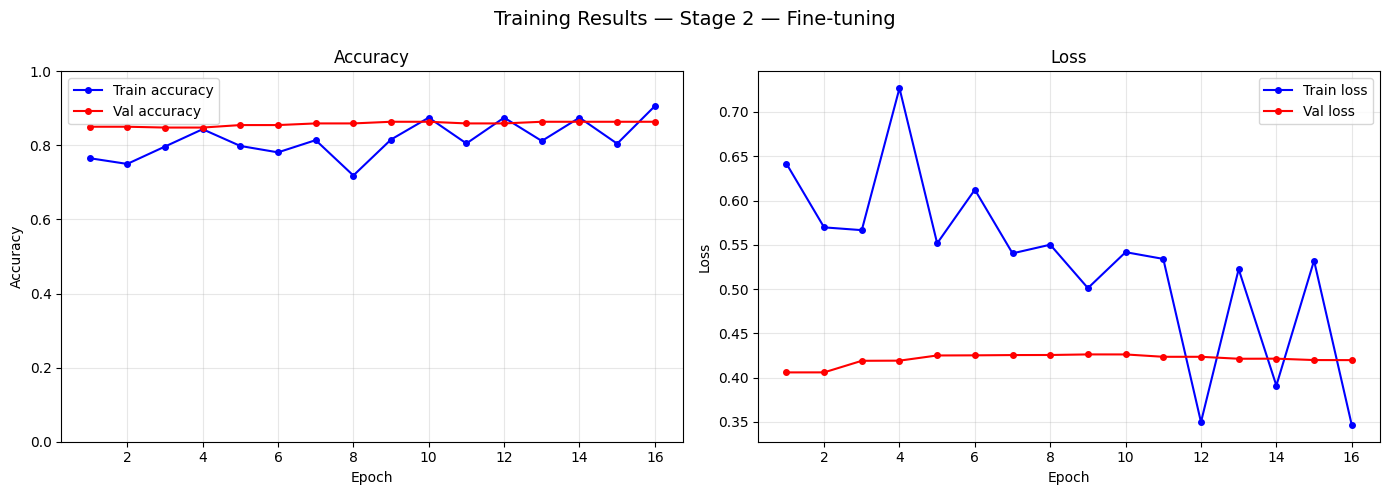

Plot saved: /content/drive/MyDrive/waste_project/plot_stage_2_—_fine-tuning.png

  ACCURACY COMPARISON
  Stage 1 (transfer):  86.38%
  Stage 2 (fine-tune): 86.38%


In [25]:
plot_history(history_stage2, "Stage 2 — Fine-tuning")

# Compare both stages side by side
print("\n" + "="*40)
print("  ACCURACY COMPARISON")
print("="*40)
print(f"  Stage 1 (transfer):  {max(history_stage1.history['val_accuracy'])*100:.2f}%")
print(f"  Stage 2 (fine-tune): {max(history_stage2.history['val_accuracy'])*100:.2f}%")
print("="*40)

In [26]:
import os

stage1_best = max(history_stage1.history['val_accuracy'])
stage2_best = max(history_stage2.history['val_accuracy'])

print("=" * 45)
print("  FINAL MODEL SELECTION")
print("=" * 45)
print(f"  Stage 1 accuracy : {stage1_best*100:.2f}%")
print(f"  Stage 2 accuracy : {stage2_best*100:.2f}%")

# Load the better model fresh — avoids shape mismatch error
if stage2_best > stage1_best:
    print("\n  Fine-tuned model is better — loading it...")
    best_model = tf.keras.models.load_model(SAVE_DIR + "waste_model_finetuned.h5")
else:
    print("\n  Stage 1 model is better — loading it...")
    best_model = tf.keras.models.load_model(SAVE_DIR + "waste_model_stage1.h5")

# Save as final model in modern .keras format (no more legacy warnings)
FINAL_MODEL_PATH = SAVE_DIR + "waste_model_FINAL.keras"
best_model.save(FINAL_MODEL_PATH)

size_mb = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)
print(f"\n  Saved: waste_model_FINAL.keras")
print(f"  Size : {size_mb:.1f} MB")
print("\n  Download this file to your PC for the Streamlit app.")

  FINAL MODEL SELECTION
  Stage 1 accuracy : 86.38%
  Stage 2 accuracy : 86.38%

  Stage 1 model is better — loading it...



  Saved: waste_model_FINAL.keras
  Size : 10.6 MB

  Download this file to your PC for the Streamlit app.


Quick sanity check:
  True label      : paper
  Predicted label : paper
  Confidence      : 99.8%
  Correct?        : YES

All class probabilities:
  cardboard   :   0.1%  
  glass       :   0.0%  
  metal       :   0.0%  
  paper       :  99.8%  █████████████████████████████
  plastic     :   0.0%  
  trash       :   0.1%  


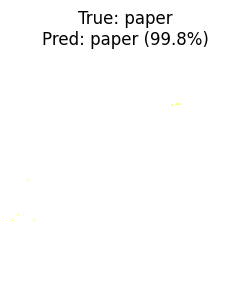

In [27]:
import cv2

# Pick one test image and predict it manually to verify everything works
sample_img = X_test[0]
sample_true_label = int(y_test[0])

# model expects a batch → add extra dimension: (224,224,3) → (1,224,224,3)
prediction = model.predict(np.expand_dims(sample_img, axis=0), verbose=0)

predicted_idx  = np.argmax(prediction[0])
confidence     = prediction[0][predicted_idx] * 100

print("Quick sanity check:")
print(f"  True label      : {CLASS_NAMES[sample_true_label]}")
print(f"  Predicted label : {CLASS_NAMES[predicted_idx]}")
print(f"  Confidence      : {confidence:.1f}%")
print(f"  Correct?        : {'YES' if predicted_idx == sample_true_label else 'NO'}")

# Show all class probabilities
print("\nAll class probabilities:")
for i, name in enumerate(CLASS_NAMES):
    bar = "█" * int(prediction[0][i] * 30)
    print(f"  {name:12s}: {prediction[0][i]*100:5.1f}%  {bar}")

# Show the image
plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title(f"True: {CLASS_NAMES[sample_true_label]}\nPred: {CLASS_NAMES[predicted_idx]} ({confidence:.1f}%)")
plt.axis('off')
plt.show()

In [28]:
# Run this in your Colab Part 2 notebook
import tensorflow as tf
import numpy as np

# Load your saved model
model = tf.keras.models.load_model(SAVE_DIR + "waste_model_FINAL.keras")

# Save ONLY the weights (version-independent)
model.save_weights(SAVE_DIR + "waste_weights_FINAL.weights.h5")
print("Weights saved!")

# Also save as TF SavedModel format (most compatible)
model.export(SAVE_DIR + "waste_savedmodel")
print("SavedModel exported!")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Weights saved!
Saved artifact at '/content/drive/MyDrive/waste_project/waste_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  131950462541008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594107600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594107984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594108560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594106448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594109328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594107792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594106640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594108176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131950594105680: TensorSpec(sha